<a href="https://colab.research.google.com/github/skyf-ux/Beijing-Air-Quality-App/blob/main/Air_Quality_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Beijing Air Quality Analysis and Prediction System

## 🌍 Project Overview
This project presents a comprehensive data science workflow for analysing and predicting air pollution levels (PM2.5) in Beijing. It integrates data preprocessing, exploratory data analysis (EDA), machine learning, and application development.

In [1]:
!git clone https://github.com/skyf-ux/Beijing-Air-Quality-App


Cloning into 'Beijing-Air-Quality-App'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 18 (delta 5), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 16.37 KiB | 5.46 MiB/s, done.
Resolving deltas: 100% (5/5), done.



# Install Required Libraries

Install all necessary Python packages for data processing, visualisation, and machine learning.



In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib


# Import Libraries

This section imports the core libraries required for data analysis and visualisation tasks.

- Pandas & NumPy are used for handling, processing, and performing numerical  computations on data.
- Matplotlib & Seaborn are used to create visual representations of the data, enabling effective exploration and interpretation.



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Uploading Files

This code allows you to upload files from your local device into Google Colab. Once executed, it opens a file selection window, and the chosen files are saved in the active session for use in data analysis tasks.



In [4]:
from google.colab import files
uploaded = files.upload()

Saving PRSA_Data_Dongsi_20130301-20170228.csv to PRSA_Data_Dongsi_20130301-20170228.csv
Saving PRSA_Data_Guanyuan_20130301-20170228.csv to PRSA_Data_Guanyuan_20130301-20170228.csv
Saving PRSA_Data_Huairou_20130301-20170228.csv to PRSA_Data_Huairou_20130301-20170228.csv
Saving PRSA_Data_Shunyi_20130301-20170228.csv to PRSA_Data_Shunyi_20130301-20170228.csv


# Importing Station Datasets

This section loads the air quality data for the chosen monitoring stations into Pandas DataFrames to support subsequent analysis and comparison.


In [5]:
dongsi = pd.read_csv("PRSA_Data_Dongsi_20130301-20170228.csv")
guanyuan = pd.read_csv("PRSA_Data_Guanyuan_20130301-20170228.csv")
shunyi = pd.read_csv("PRSA_Data_Shunyi_20130301-20170228.csv")
huairou = pd.read_csv("PRSA_Data_Huairou_20130301-20170228.csv")

# Adding Station Labels

This section assigns a station name to each dataset, enabling records from different monitoring locations to be identified after the datasets are combined.


In [6]:
dongsi["station"] = "Dongsi"
guanyuan["station"] = "Guanyuan"
shunyi["station"] = "Shunyi"
huairou["station"] = "Huairou"

# Combining Datasets

This section merges the separate station datasets into one consolidated DataFrame, enabling integrated analysis of all selected monitoring stations.


In [7]:
data = pd.concat([dongsi, guanyuan, shunyi, huairou], ignore_index=True)

print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (140256, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi


# Generating Datetime Column

This section creates a single datetime feature by combining the year, month, day, and hour columns, then arranges the dataset in chronological order for time-based analysis.


In [8]:
data["datetime"] = pd.to_datetime(data[["year","month","day","hour"]])

data = data.sort_values("datetime")

data.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi,2013-03-01 00:00:00
35064,1,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan,2013-03-01 00:00:00
70128,1,2013,3,1,0,3.0,6.0,3.0,8.0,300.0,44.0,-0.9,1025.8,-20.5,0.0,NW,9.3,Shunyi,2013-03-01 00:00:00
105192,1,2013,3,1,0,7.0,7.0,3.0,2.0,100.0,91.0,-2.3,1020.3,-20.7,0.0,WNW,3.1,Huairou,2013-03-01 00:00:00
35065,2,2013,3,1,1,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan,2013-03-01 01:00:00


#Dataset Information

View the dataset structure, data types, and non-missing values to gain an overview of the dataset composition.

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140256 entries, 0 to 140255
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   No        140256 non-null  int64         
 1   year      140256 non-null  int64         
 2   month     140256 non-null  int64         
 3   day       140256 non-null  int64         
 4   hour      140256 non-null  int64         
 5   PM2.5     137024 non-null  float64       
 6   PM10      137949 non-null  float64       
 7   SO2       136843 non-null  float64       
 8   NO2       134992 non-null  float64       
 9   CO        131706 non-null  float64       
 10  O3        135779 non-null  float64       
 11  TEMP      140114 non-null  float64       
 12  PRES      140112 non-null  float64       
 13  DEWP      140109 non-null  float64       
 14  RAIN      140110 non-null  float64       
 15  wd        139312 non-null  object        
 16  WSPM      140135 non-null  float64       
 


#Missing Values Check

Examine missing values across all columns to evaluate dataset completeness.
```


In [10]:
data.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,3232
PM10,2307
SO2,3413
NO2,5264
CO,8550


# Statistical Summary and Missing Values
Produce summary statistics and inspect missing values to evaluate data characteristics and completeness.

In [11]:
data.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,datetime
count,140256.000,140256.000000,140256.000000,140256.000000,140256.000000,137024.000000,137949.000000,136843.000000,134992.000000,131706.000000,135779.000000,140114.000000,140112.000000,140109.000000,140110.000000,140135.000000,140256
mean,17532.500,2014.662560,6.522930,15.729637,11.500000,79.579509,102.418485,15.473286,47.076537,1200.947307,57.013350,13.272530,1011.264177,2.568666,0.065119,1.757224,2015-03-01 11:30:00
min,1.000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.800000,-43.400000,0.000000,0.000000,2013-03-01 00:00:00
25%,8766.750,2014.000000,4.000000,8.000000,5.750000,20.000000,34.000000,2.000000,21.000000,500.000000,12.000000,3.000000,1002.900000,-8.900000,0.000000,0.900000,2014-03-01 05:45:00
50%,17532.500,2015.000000,7.000000,16.000000,11.500000,55.000000,80.000000,7.000000,40.000000,900.000000,45.000000,14.300000,1010.900000,3.200000,0.000000,1.400000,2015-03-01 11:30:00
75%,26298.250,2016.000000,10.000000,23.000000,17.250000,111.000000,142.000000,19.000000,66.000000,1500.000000,81.000000,23.100000,1019.425000,15.300000,0.000000,2.200000,2016-02-29 17:15:00
max,35064.000,2017.000000,12.000000,31.000000,23.000000,941.000000,999.000000,315.000000,270.000000,10000.000000,1071.000000,41.100000,1042.800000,29.100000,72.500000,12.900000,2017-02-28 23:00:00
std,10122.141,1.177201,3.448715,8.800123,6.922211,80.433210,91.054730,21.524836,33.320134,1113.648561,56.295033,11.534021,10.443904,13.824228,0.828778,1.246207,NaN


# Remove Duplicate Records

Remove duplicate entries to maintain data quality and preserve unique observations.

In [12]:
data.drop_duplicates(inplace=True)

## Handle Missing Values

Use forward fill to impute missing values while maintaining continuity in the time-series data.

In [13]:
data.fillna(method="ffill", inplace=True)

/tmp/ipykernel_2560/3219607963.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method="ffill", inplace=True)




#Time-Based Feature Extraction

This step derives key time features—year, month, day, and hour—from the `datetime` column. These variables help reveal patterns in air pollution over time, including seasonal changes and hourly fluctuations, which can enhance both analysis and model accuracy.



In [14]:
data["year"] = data["datetime"].dt.year
data["month"] = data["datetime"].dt.month
data["day"] = data["datetime"].dt.day
data["hour"] = data["datetime"].dt.hour

#Air Quality Index (AQI) Categorisation

This step groups PM2.5 concentrations into defined air quality categories—Good, Moderate, Unhealthy, and Hazardous. This makes pollution levels easier to interpret and supports clearer analysis and visualisation.



In [15]:
def aqi_level(pm):
    if pm <= 50:
        return "Good"
    elif pm <= 100:
        return "Moderate"
    elif pm <= 150:
        return "Unhealthy"
    else:
        return "Hazardous"

data["AQI_level"] = data["PM2.5"].apply(aqi_level)

### 📊 PM2.5 Distribution

This chart illustrates how PM2.5 values are distributed in the dataset. It highlights the range, typical concentrations, and any skewness or presence of unusually high pollution levels.


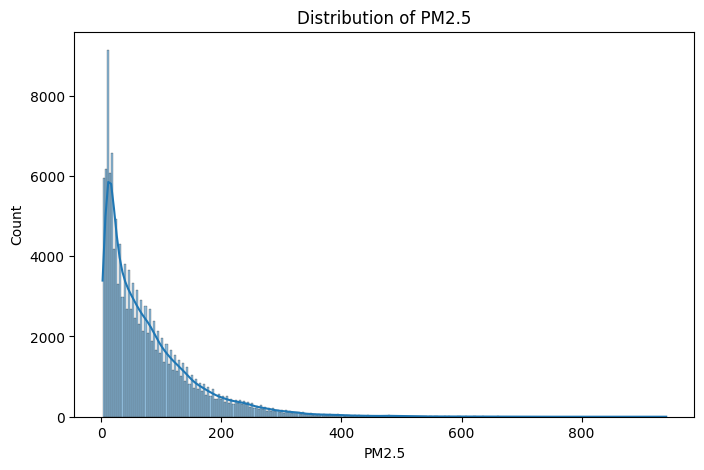

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(data["PM2.5"], kde=True)

plt.title("Distribution of PM2.5")
plt.show()

#Temperature Distribution

This chart shows the spread of temperature values in the dataset. It helps reveal common temperature ranges, variation, and any outliers or extreme conditions.


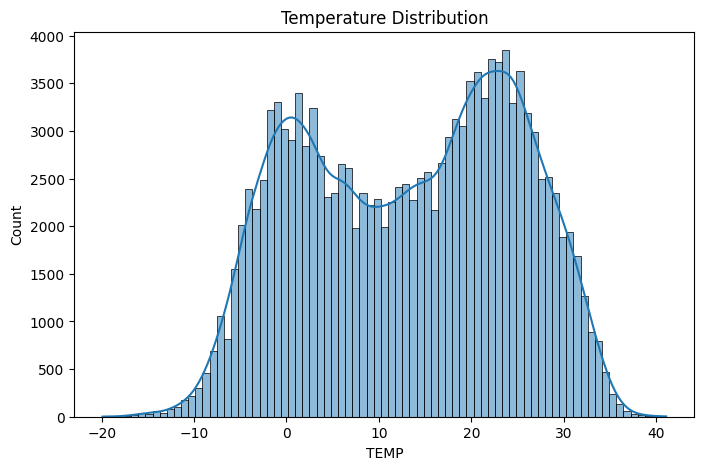

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(data["TEMP"], kde=True)

plt.title("Temperature Distribution")
plt.show()

#PM2.5 vs Temperature

This scatter plot illustrates how PM2.5 concentrations change with temperature. It is used to detect any potential patterns or relationships between temperature variations and air pollution levels.



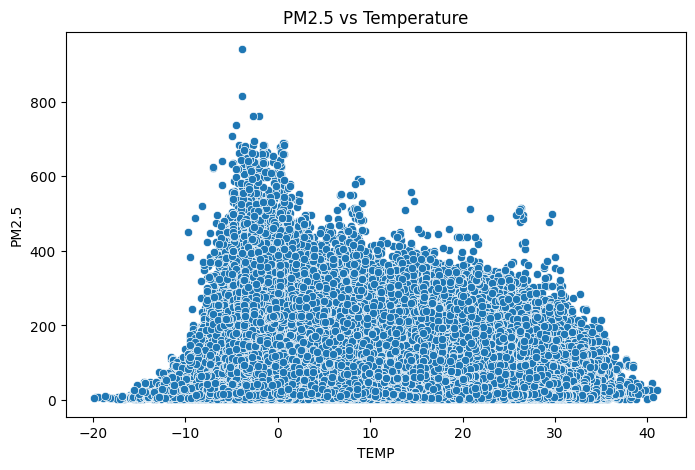

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="TEMP", y="PM2.5", data=data)

plt.title("PM2.5 vs Temperature")
plt.show()

# NO2 vs O3 Relationship

This scatter plot illustrates how NO2 and O3 concentrations relate to each other. It is used to identify any correlation or interaction between these two air pollutants.


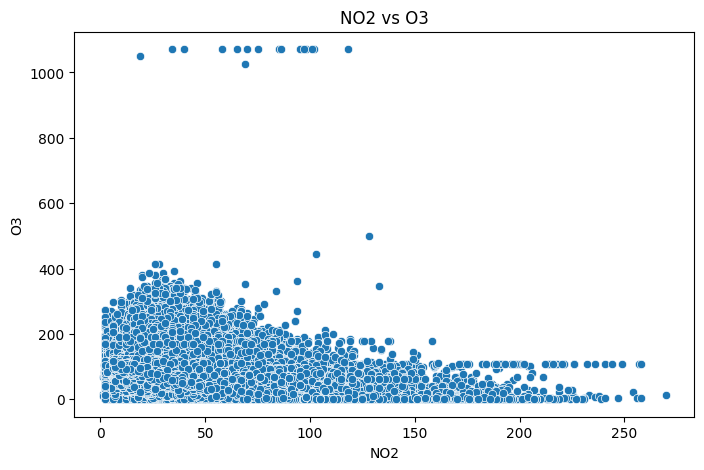

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="NO2", y="O3", data=data)

plt.title("NO2 vs O3")
plt.show()